In [2]:
import numpy as np
from zfish._io import import16chFlt
import matplotlib.pyplot as plt
from tqdm import tqdm
from zfish.utils import *
from zfish.swim import *
from zfish.local_path import *

code_id = "5006 - CloseLoop 1D"
loc = join(figpath, code_id)
mkdir(loc)
pass

        D:\Yao Shuyang\En Lab\Results\5006 - CloseLoop 1D is already existed!


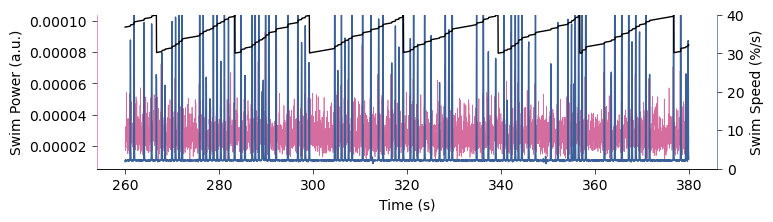

In [5]:
res = import16chFlt(r"F:\Light-sheet\10138\S3\res.16chFlt")
for k in res.keys():
    res[k] = res[k][::120]

idx = np.where((np.diff(res['behav_pos_y']) < 0)|(res['behav_pos_y'][:-1] >100))[0]
for k in res.keys():
    res[k] = np.delete(res[k], idx+1)

idx = np.where(res['behav_time'] > 5)[0]
res['behav_pos_y'] *= 2
x = res['behav_pos_y']//1

pos = res['behav_pos_y'] + 100 * res['n_trials']
dx = np.diff(pos)
dt = np.diff(res['behav_time'])
speed = np.convolve(dx, np.ones(5), mode='same')/np.convolve(dt, np.ones(5), mode='same')
speed = np.append(speed, speed[-1])

tidx  = np.where((res['behav_time'] > 260) & (res['behav_time'] < 380))[0]
plt.figure(figsize=(8, 2))
ax = Clear_Axes(plt.axes(), close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
axt = Clear_Axes(ax.twinx(), close_spines=['top', 'left'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x=res['behav_time'][tidx], 
    y=res['fltCh1'][tidx], 
    ax=ax, 
    color=ChannelColors[0],
    linewidth=0.5
)
ax.set_ylabel("Swim Power (a.u.)")
sns.lineplot(
    x=res['behav_time'][tidx], 
    y=speed[tidx], 
    ax=axt, 
    color=ChannelColors[1],
    linewidth=1
)
axt.plot(res['behav_time'][tidx], res['behav_pos_y'][tidx]/10+30, color='k', linewidth=1, label="Position")
axt.set_ylabel("Swim Speed (%/s)")
axt.set_ylim(0, 40)
ax.set_xlabel("Time (s)")
# Adjust spine color
ax.spines['left'].set_color(ChannelColors[0])
axt.spines['right'].set_color(ChannelColors[1])